<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/simulation/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
NUM_NODES = 30
CONNECTION_PROB = 0.12
NOISE_LEVEL = 0.55
PRUNE_THRESHOLD = 0.18
ITERATIONS = 20

In [3]:
G = nx.DiGraph()

for i in range(NUM_NODES):
    G.add_node(i, value=random.uniform(-1, 1))

for i in range(NUM_NODES):
    for j in range(NUM_NODES):
        if i != j and random.random() < CONNECTION_PROB:
            G.add_edge(i, j, weight=random.uniform(0.1, 1.0))

In [4]:
def add_noise(G):
    for n in G.nodes:
        G.nodes[n]["value"] += random.uniform(-NOISE_LEVEL, NOISE_LEVEL)

def forward_pass(G):
    new_values = {}
    for n in G.nodes:
        total = 0.0
        for pred in G.predecessors(n):
            total += G.nodes[pred]["value"] * G[pred][n]["weight"]
        new_values[n] = total
    return new_values

def normalize(G, new_values):
    total = sum(abs(v) for v in new_values.values()) + 1e-6
    for n in G.nodes:
        G.nodes[n]["value"] = new_values[n] / total

def reinforce(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= random.uniform(0.95, 1.08)

def decay(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= 0.94

def prune(G):
    to_remove = []
    for u, v in G.edges:
        if abs(G[u][v]["weight"]) < PRUNE_THRESHOLD:
            to_remove.append((u, v))
    for e in to_remove:
        G.remove_edge(*e)
    return len(to_remove)

def coherence(G):
    vals = [G.nodes[n]["value"] for n in G.nodes]
    mean = sum(vals) / len(vals)
    var = sum((v - mean) ** 2 for v in vals) / len(vals)
    return 1 / (1 + var)

def detect_bindu(G):
    centrality = nx.degree_centrality(G)
    node = max(centrality, key=centrality.get)
    return node, centrality[node]

In [5]:
def draw_graph(G, step, coh):
    plt.figure(figsize=(7, 7))
    pos = nx.spring_layout(G, seed=42)

    bindu, strength = detect_bindu(G)

    colors = []
    sizes = []

    for n in G.nodes:
        v = G.nodes[n]["value"]

        if v >= 0:
            colors.append((1 - min(abs(v), 1), 0.2, min(abs(v), 1)))
        else:
            colors.append((min(abs(v), 1), 0.2, 1 - min(abs(v), 1)))

        sizes.append(420 if n == bindu else 120)

    nx.draw(
        G,
        pos,
        node_color=colors,
        node_size=sizes,
        edge_color="gray",
        alpha=0.85,
        with_labels=False
    )

    plt.title(f"Step {step} | Coherence {coh:.3f} | Bindu {bindu}")
    plt.show()

=== V-KERNEL DEMO START ===
[STEP 0] coherence=0.9982 edges=87 pruned=17 bindu=10 strength=0.345


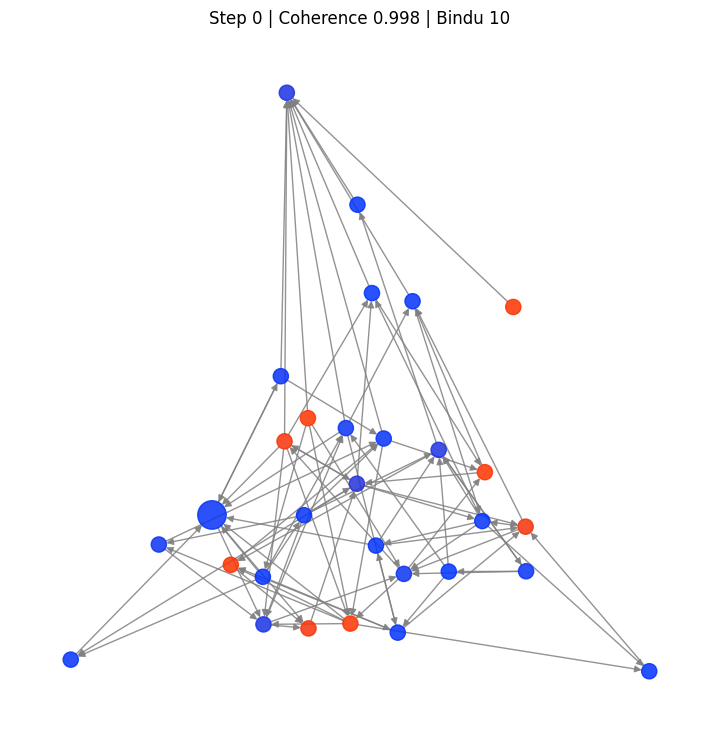

[STEP 1] coherence=0.9982 edges=87 pruned=0 bindu=10 strength=0.345
[STEP 2] coherence=0.9980 edges=86 pruned=1 bindu=0 strength=0.310
[STEP 3] coherence=0.9980 edges=86 pruned=0 bindu=0 strength=0.310
[STEP 4] coherence=0.9984 edges=84 pruned=2 bindu=10 strength=0.310
[STEP 5] coherence=0.9981 edges=83 pruned=1 bindu=10 strength=0.310


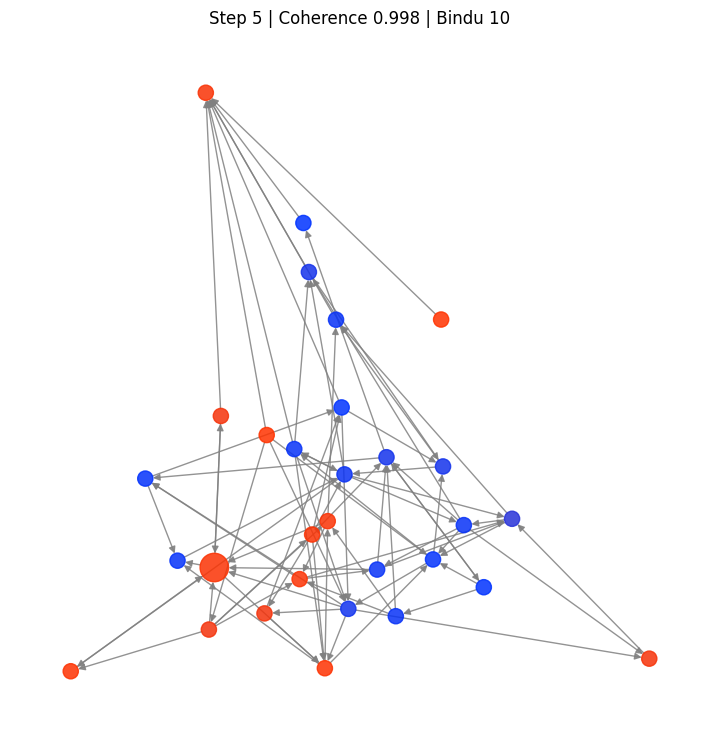

[STEP 6] coherence=0.9983 edges=83 pruned=0 bindu=10 strength=0.310
[STEP 7] coherence=0.9978 edges=82 pruned=1 bindu=10 strength=0.310
[STEP 8] coherence=0.9982 edges=81 pruned=1 bindu=10 strength=0.310
[STEP 9] coherence=0.9982 edges=81 pruned=0 bindu=10 strength=0.310
[STEP 10] coherence=0.9976 edges=80 pruned=1 bindu=10 strength=0.310


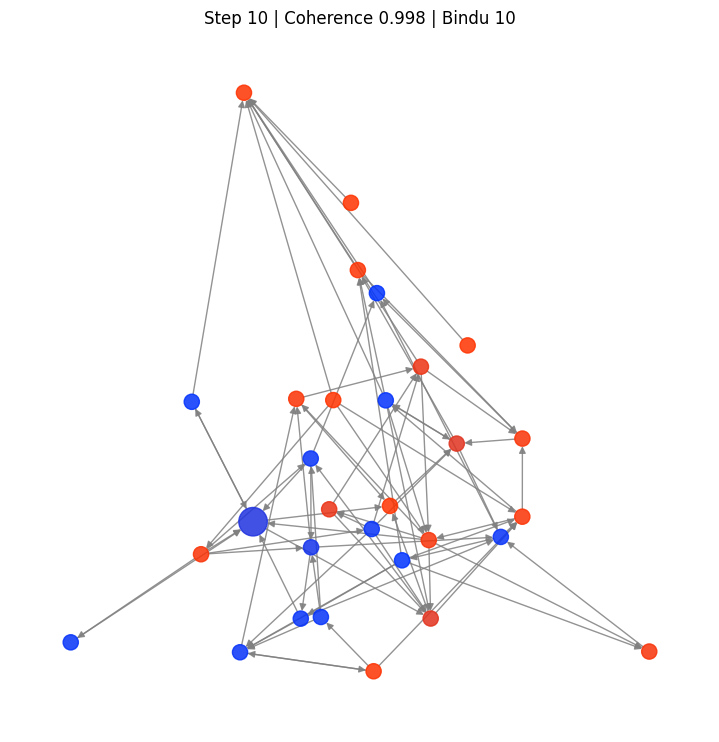

[STEP 11] coherence=0.9984 edges=79 pruned=1 bindu=10 strength=0.310
[STEP 12] coherence=0.9980 edges=77 pruned=2 bindu=10 strength=0.310
[STEP 13] coherence=0.9985 edges=75 pruned=2 bindu=26 strength=0.310
[STEP 14] coherence=0.9980 edges=73 pruned=2 bindu=26 strength=0.310
[STEP 15] coherence=0.9979 edges=73 pruned=0 bindu=26 strength=0.310


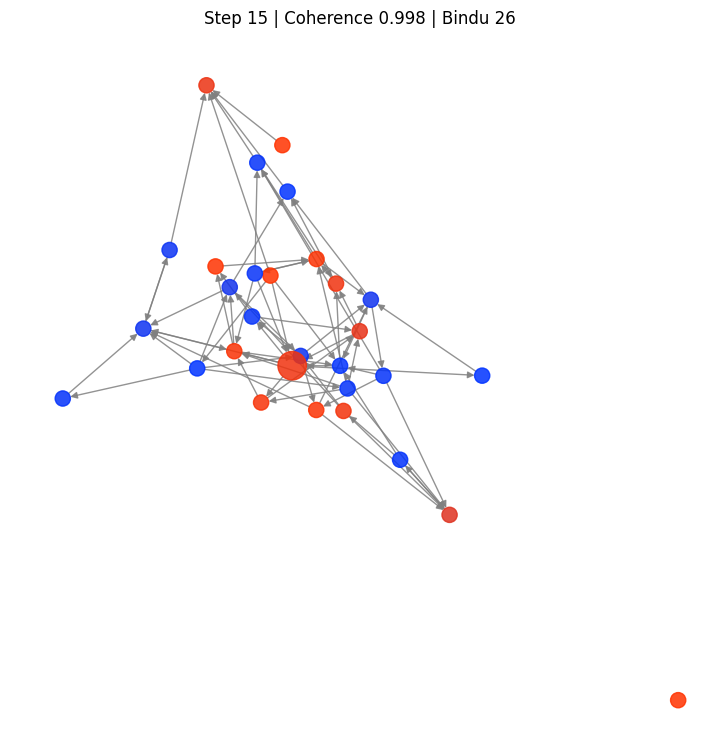

[STEP 16] coherence=0.9983 edges=70 pruned=3 bindu=26 strength=0.310
[STEP 17] coherence=0.9984 edges=69 pruned=1 bindu=26 strength=0.310
[STEP 18] coherence=0.9984 edges=67 pruned=2 bindu=26 strength=0.310
[STEP 19] coherence=0.9981 edges=66 pruned=1 bindu=26 strength=0.310


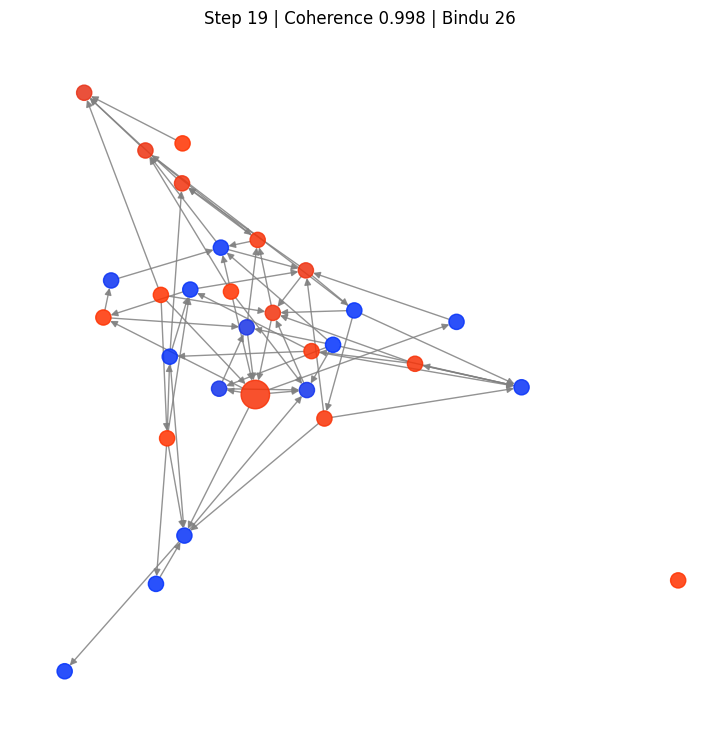

=== V-KERNEL DEMO END ===


In [6]:
history_coh = []
history_edges = []
history_pruned = []

print("=== V-KERNEL DEMO START ===")

for step in range(ITERATIONS):
    add_noise(G)

    new_vals = forward_pass(G)
    normalize(G, new_vals)

    reinforce(G)
    decay(G)

    removed = prune(G)
    coh = coherence(G)
    bindu, strength = detect_bindu(G)

    history_coh.append(coh)
    history_edges.append(G.number_of_edges())
    history_pruned.append(removed)

    print(
        f"[STEP {step}] coherence={coh:.4f} "
        f"edges={G.number_of_edges()} pruned={removed} "
        f"bindu={bindu} strength={strength:.3f}"
    )

    if step in [0, 5, 10, 15, ITERATIONS - 1]:
        draw_graph(G, step, coh)

print("=== V-KERNEL DEMO END ===")

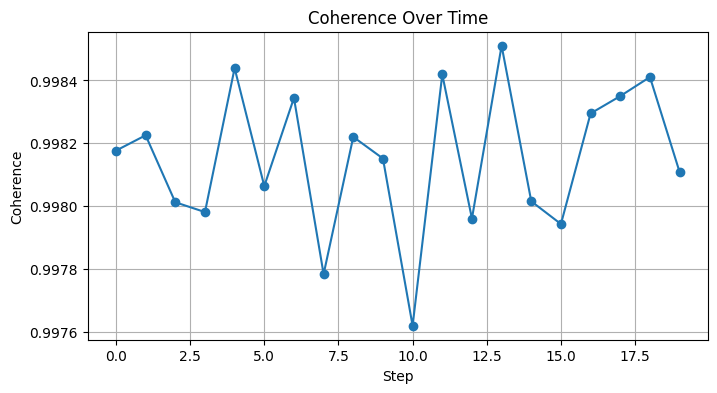

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history_coh, marker="o")
plt.title("Coherence Over Time")
plt.xlabel("Step")
plt.ylabel("Coherence")
plt.grid(True)
plt.show()

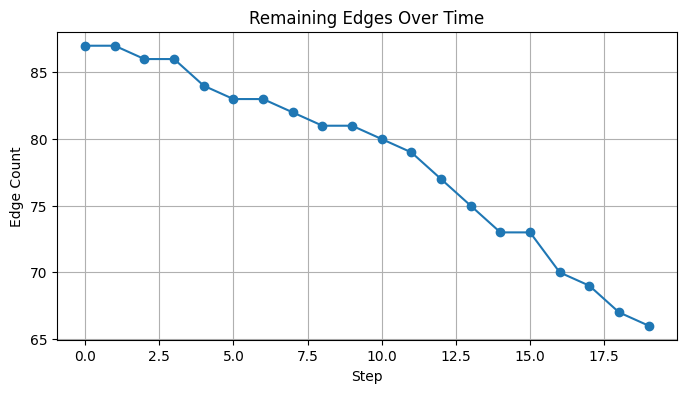

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history_edges, marker="o")
plt.title("Remaining Edges Over Time")
plt.xlabel("Step")
plt.ylabel("Edge Count")
plt.grid(True)
plt.show()

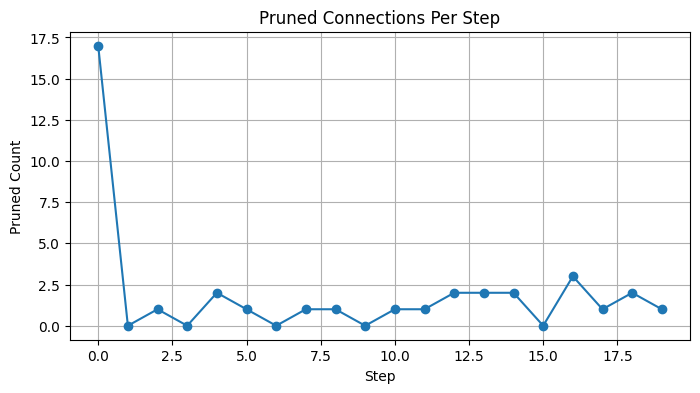

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(history_pruned, marker="o")
plt.title("Pruned Connections Per Step")
plt.xlabel("Step")
plt.ylabel("Pruned Count")
plt.grid(True)
plt.show()